In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, mean_squared_error, mean_absolute_error, r2_score, roc_curve
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# 1. Workflow

## 1.1. Load & Inspect Dataset

In [115]:
df = pd.read_csv('B.csv')
df = df.drop('student_id', axis=1)

In [116]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (5000, 17)

Data Types:
 gender                         object
ssc_percentage                  int64
hsc_percentage                  int64
degree_percentage               int64
cgpa                          float64
entrance_exam_score             int64
technical_skill_score           int64
soft_skill_score                int64
internship_count                int64
live_projects                   int64
work_experience_months          int64
certifications                  int64
attendance_percentage           int64
backlogs                        int64
extracurricular_activities     object
placement_status                int64
salary_package_lpa            float64
dtype: object


Data type sudah benar sehingga tidek perlu diubah.

In [117]:
print("First 5 rows:")
df.head()

First 5 rows:


,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


### 1.1.1 Basic Stratistics

In [118]:
print("Descriptive Statistics")
print(df.describe())

Descriptive Statistics
       ssc_percentage  hsc_percentage  degree_percentage         cgpa  \
count     5000.000000     5000.000000        5000.000000  5000.000000   
mean        72.425800       71.910800          71.845200     7.678326   
std         13.199642       12.842781          10.013196     1.237084   
min         50.000000       50.000000          55.000000     5.500000   
25%         61.000000       61.000000          63.000000     6.617500   
50%         72.000000       72.000000          72.000000     7.700000   
75%         84.000000       83.000000          80.000000     8.750000   
max         95.000000       94.000000          89.000000     9.800000   

       entrance_exam_score  technical_skill_score  soft_skill_score  \
count          5000.000000            5000.000000       5000.000000   
mean             69.197800              69.651000         69.839600   
std              17.325528              17.179704         17.170732   
min              40.000000         

In [119]:
print("Target Distribution")
print("placement_status value counts:")
print(df['placement_status'].value_counts())
print(f"\nPlacement rate: {df['placement_status'].mean():.1%}")


Target Distribution
placement_status value counts:
placement_status
0    4134
1     866
Name: count, dtype: int64

Placement rate: 17.3%


Jumlah value pada placement_status imbalance, sehingga perlu dilakuakn class weighting

In [120]:
print("Salary (placed students only)")
placed = df[df['placement_status'] == 1]['salary_package_lpa']
print(f"Count: {len(placed)}")
print(f"Mean:  {placed.mean():.2f} LPA")
print(f"Std:   {placed.std():.2f} LPA")
print(f"Range: {placed.min():.2f} – {placed.max():.2f} LPA")


Salary (placed students only)
Count: 866
Mean:  9.21 LPA
Std:   3.48 LPA
Range: 3.01 – 14.99 LPA


## 1.2. Initial Corelation Analysis 

In [121]:
numerical_df = df.select_dtypes(include=['number'])

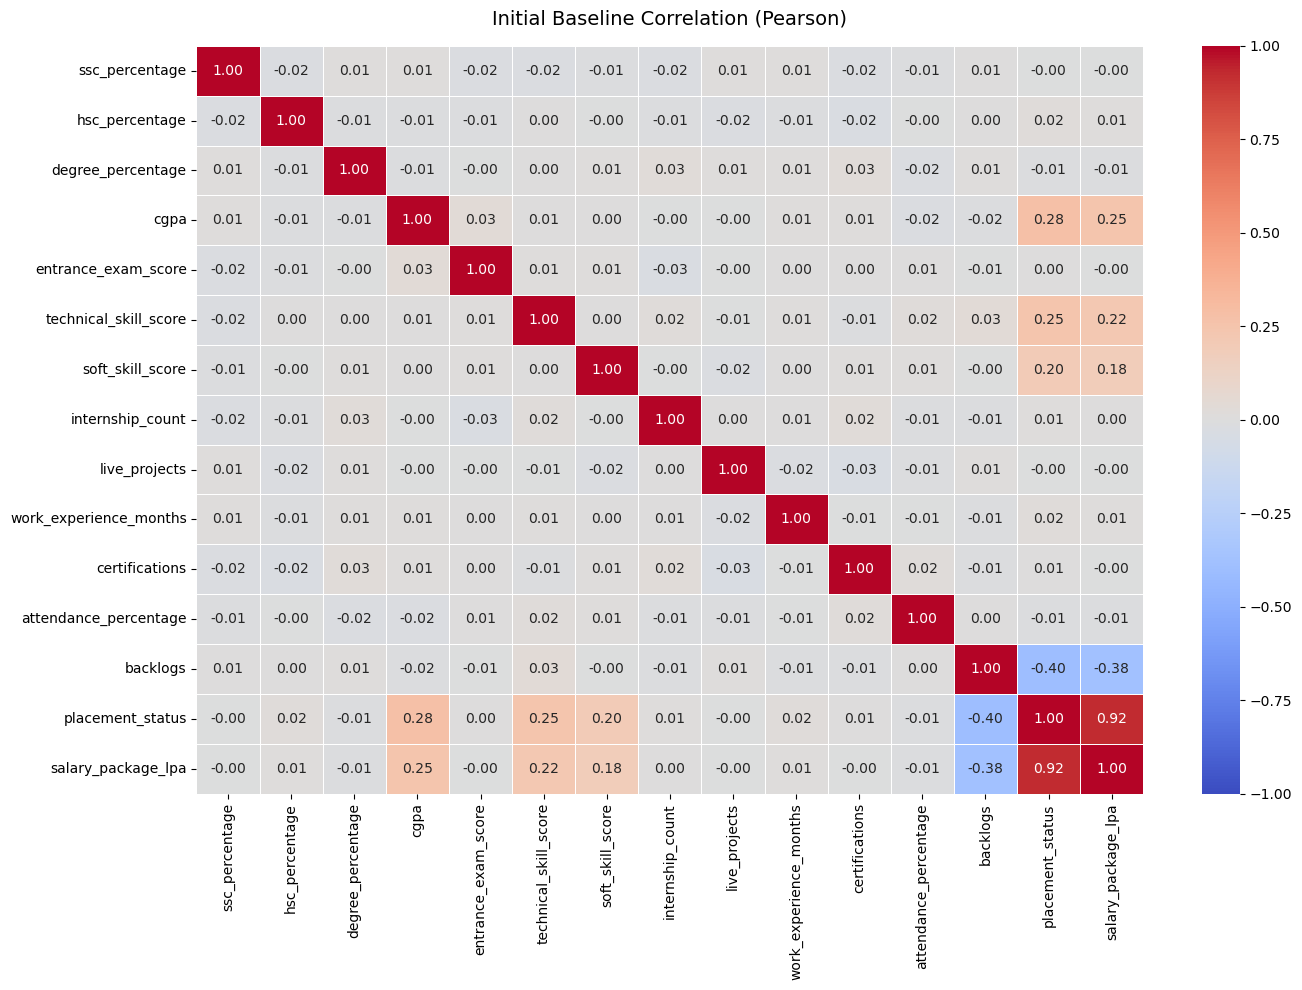

In [122]:
pearson_corr = numerical_df.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    center=0,
    vmin=-1, vmax=1
)
plt.title("Initial Baseline Correlation (Pearson)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


Pearson unutk menunjukkan standard baseline antara continuous numerical percentages  
  
1. placement_status & salary_package_lpa memiliki hubungan yang kental karena gaji hanya didapatkan ketika sudah mendapatkan pekerjaan.  
2. backlogs & placement_status & salary_package_lpa memiliki negative correlation menunjukkan bahwa mahasiswa dengan lebih banyak mata kuliah yang belum lulus (gagal/tertunda) memiliki kemungkinan yang jauh lebih kecil untuk mendapatkan pekerjaan sehingga tidak mendapatkan gaji.  
3. cgpa & technical_skill_score & soft_skill_score merupakan ketiga variabel  merupakan positive predictor terkuat.  

## 1.3. Data Cleaning

In [123]:
print("Missing Values")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing Values
No missing values found.


In [124]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after deduplication: {df.shape}")


Duplicate rows: 0
Shape after deduplication: (5000, 17)


In [125]:
print("\nCategorical Columns")
for col in ['gender', 'extracurricular_activities']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categorical Columns

gender:
gender
Male      2504
Female    2496
Name: count, dtype: int64

extracurricular_activities:
extracurricular_activities
No     2553
Yes    2447
Name: count, dtype: int64


In [126]:
print("\nPercentage Range")
range_checks = {
    'ssc_percentage': (0, 100),
    'hsc_percentage': (0, 100),
    'degree_percentage': (0, 100),
    'cgpa': (0, 10),
    'attendance_percentage': (0, 100),
}
for col, (lo, hi) in range_checks.items():
    out = df[(df[col] < lo) | (df[col] > hi)]
    if len(out) > 0:
        print(f"  {col}: {len(out)}")
    else:
        print(f"  {col}: {lo}–{hi}")



Percentage Range
  ssc_percentage: 0–100
  hsc_percentage: 0–100
  degree_percentage: 0–100
  cgpa: 0–10
  attendance_percentage: 0–100


## 1.4. Feature Engineering

In [127]:
# Encode categoricals
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['extracurricular_activities'] = df['extracurricular_activities'].map({'No': 0, 'Yes': 1})

In [128]:
# Composite features
df['academic_composite'] = df[['ssc_percentage', 'hsc_percentage', 'degree_percentage']].mean(axis=1)
df['skill_composite'] = df[['technical_skill_score', 'soft_skill_score']].mean(axis=1)
df['experience_score'] = (
    df['internship_count'] * 3 +
    df['live_projects'] * 2 +
    df['work_experience_months'] * 0.5
)

In [129]:
print("New features:")
print(df[['academic_composite', 'skill_composite', 'experience_score']].describe())
print("\nNew shape:", df.shape)

New features:
       academic_composite  skill_composite  experience_score
count         5000.000000      5000.000000       5000.000000
mean            72.060600        69.745300         16.938000
std              6.929829        12.174413          6.513535
min             52.333333        40.000000          0.000000
25%             67.333333        61.000000         12.500000
50%             72.000000        70.000000         17.000000
75%             77.000000        78.500000         21.500000
max             92.000000        99.000000         34.000000

New shape: (5000, 20)


1. academi_composite: Menggabungkan semua tahapan akademik menjadi satu.  
2. skill_composite: Menggabungkan hard + soft skills.  
3. experience_score: Weighted indeks pengalaman praktis.  

## 1.5. Final Corelation Analysis

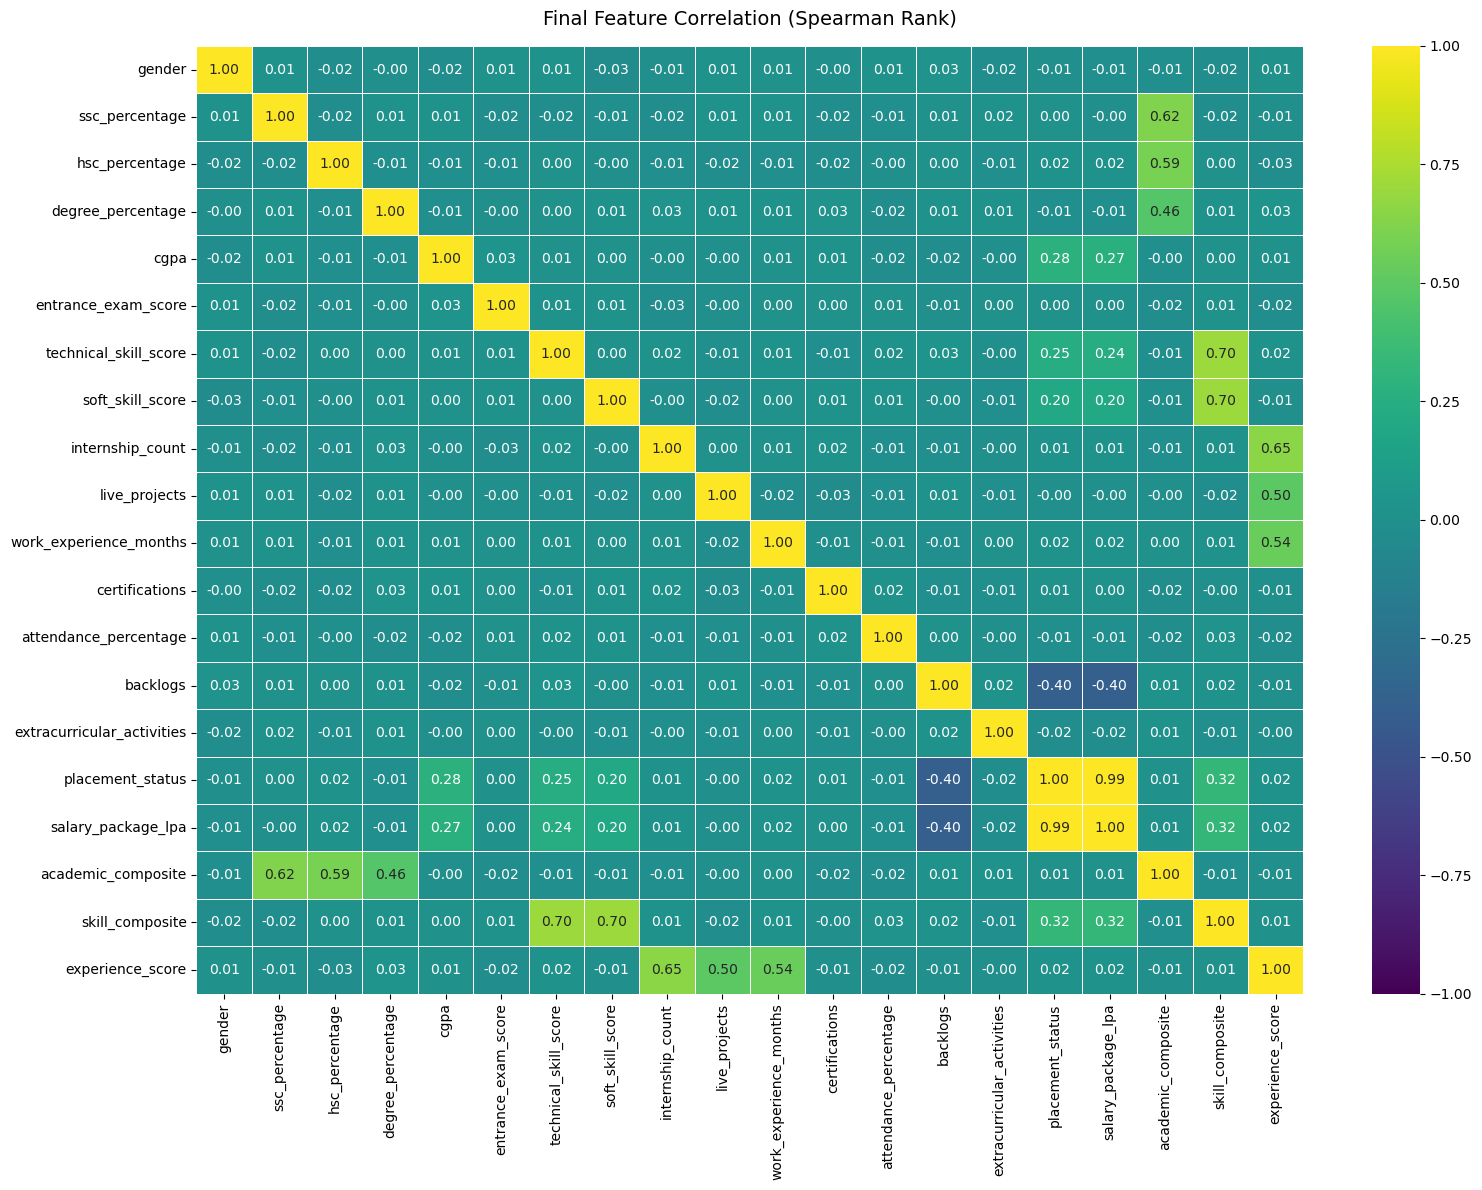

In [130]:
spearman_corr = df.corr(method='spearman')

plt.figure(figsize=(16, 12))
mask = None  
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Final Feature Correlation (Spearman Rank)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Spearman lebih robust terhadap non-linearity dan outliers.  
  
1. academic_composie memiliki relasi yang kuat dengan ssc_percentage, hsc_percentage, dna degree_percentage, menunjukkan bahwa variable baru berhasil merangkum seluruh riwayat akademik siswa menjadi satu angka.  
2. skill_composite memiliki relasi yang kuat dengan technical dan soft skill, tetapi lebih kuat lagi dengan placement_status dibaningkan dengna technicak atau soft skill dengna sendirinya. Hal ini menunjukkan bahwa variable baru bekerja lebih baik sebagia predictor dibandingkan kedua variable sebelumnya.  
3. backlogs masih menjadi faktor negative terkuat bagi recruiter.  
4. cgpa dan skill_composite adalah faktor positive terkuat bagi placement_status.   

In [131]:
print("Top correlations with placement_status")
target_corr = spearman_corr['placement_status'].drop(['placement_status', 'salary_package_lpa'])
print(target_corr.abs().sort_values(ascending=False).head(10))

Top correlations with placement_status
backlogs                      0.400941
skill_composite               0.323519
cgpa                          0.277102
technical_skill_score         0.246456
soft_skill_score              0.196980
work_experience_months        0.021340
experience_score              0.019010
extracurricular_activities    0.017784
hsc_percentage                0.017472
degree_percentage             0.012146
Name: placement_status, dtype: float64


## 1.6. Train-Test Splitting

In [132]:
FEATURE_COLS = [c for c in df.columns if c not in ['placement_status', 'salary_package_lpa']]
X = df[FEATURE_COLS]
y_class = df['placement_status']
y_reg   = df['salary_package_lpa']

In [133]:
# Classification split (stratified)
X_train_clf, X_test_clf, y_train_clf, y_test_clf, y_train_reg_raw, y_test_reg_raw = train_test_split(
    X, y_class, y_reg,
    test_size=0.20,
    stratify=y_class,
    random_state=42
)

In [134]:
# Regression split (label == 1)
train_placed = y_train_clf == 1
test_placed  = y_test_clf  == 1
X_train_reg = X_train_clf[train_placed]
y_train_reg = y_train_reg_raw[train_placed]
X_test_reg  = X_test_clf[test_placed]
y_test_reg  = y_test_reg_raw[test_placed]

In [135]:
print(f"Classification-Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"  Class balance in train: {y_train_clf.value_counts().to_dict()}")
print(f"  Class balance in test:  {y_test_clf.value_counts().to_dict()}")
print(f"\nRegression—Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")

Classification-Train: (4000, 18), Test: (1000, 18)
  Class balance in train: {0: 3307, 1: 693}
  Class balance in test:  {0: 827, 1: 173}

Regression—Train: (693, 18), Test: (173, 18)


In [136]:
# Scale features 
scaler = StandardScaler()
X_train_clf_sc = scaler.fit_transform(X_train_clf)
X_test_clf_sc  = scaler.transform(X_test_clf)
X_train_reg_sc = scaler.transform(X_train_reg)   
X_test_reg_sc  = scaler.transform(X_test_reg)


# 2. Modeling

## 2.1. Classification

### 2.1.1. Modeling

In [137]:
clf_models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42),
}

clf_results = {}

Alasan pemilihan model  
1. Logistic Regression: Matriks korelasi menunjukkan bahwa `cgpa` (0.28) dan `backlogs` (−0.40) memiliki arah hubungan yang jelas dan monoton terhadap `placement_status`, di mana semakin tinggi CGPA dan semakin rendah jumlah backlog, semakin besar probabilitas penempatan. Hubungan linier-monoton seperti ini adalah kondisi ideal bagi Logistic Regression, yang bekerja dengan memodelkan log-odds sebagai kombinasi linier fitur. Selain itu, variabel seperti `gender` (−0.01) dan `extracurricular_activities` (−0.02) memiliki korelasi mendekati nol. Logistic Regression secara alami menangani noise ini melalui koefisien regresi—variabel dengan hubungan lemah akan mendapatkan bobot mendekati nol, sehingga model sendiri yang melakukan seleksi implisit. Koefisien yang dihasilkan juga mudah diinterpretasikan sebagai odds ratio.   
2. Random Forest: Meskipun beberapa hubungan bersifat linier, korelasi Spearman yang relatif rendah (mayoritas di bawah 0.30) mengindikasikan bahwa hubungan antar fitur mungkin non-linier atau bersifat interaktif. Misalnya, kombinasi `cgpa` tinggi + `backlogs` rendah + `skill_composite` tinggi mungkin memiliki efek sinergis yang tidak dapat ditangkap oleh model linier. Random Forest, sebagai ensemble of decision trees mampu menangkap interaksi fitur orde tinggi tanpa perlu spesifikasi eksplisit. Selain itu, Random Forest robust terhadap outlier dan tidak memerlukan normalisasi fitur, cocok untuk dataset dengan skala yang bervariasi (persentase 0–100 vs. CGPA 0–10 vs. skor skill 0–100).
3. Gradient Boosting: Beberapa fitur seperti `certifications` (0.02), `attendance_percentage` (−0.01), dan `live_projects` (0.01) menunjukkan korelasi yang hampir nol secara individual terhadap target. Namun, fitur-fitur lemah ini mungkin informatif secara kondisional, artinya mereka hanya penting dalam konteks kombinasi fitur tertentu. Gradient Boosting membangun pohon secara iteratif dengan fokus pada residual error dari iterasi sebelumnya, sehingga mampu mengekstrak sinyal lemah yang diabaikan model lain. Algoritma ini dipilih sebagai pembanding kuat untuk menguji apakah ada pola non-linier tersembunyi yang tidak tertangkap oleh Logistic Regression maupun Random Forest standar.

In [138]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_clf)
for name, model in clf_models.items():
    model.fit(X_train_clf_sc, y_train_clf, sample_weight=sample_weights)
    y_pred  = model.predict(X_test_clf_sc)
    y_proba = model.predict_proba(X_test_clf_sc)[:, 1]

    cv_auc = cross_val_score(model, X_train_clf_sc, y_train_clf,
                              cv=5, scoring='roc_auc').mean()

    clf_results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test_clf, y_pred),
        'f1':       f1_score(y_test_clf, y_pred),
        'roc_auc':  roc_auc_score(y_test_clf, y_proba),
        'cv_auc':   cv_auc,
    }
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  Accuracy : {clf_results[name]['accuracy']:.4f}")
    print(f"  F1-Score : {clf_results[name]['f1']:.4f}")
    print(f"  ROC-AUC  : {clf_results[name]['roc_auc']:.4f}")
    print(f"  CV AUC   : {cv_auc:.4f}  (train, 5-fold)")
    print(classification_report(y_test_clf, y_pred, target_names=['Not Placed', 'Placed']))


Logistic Regression
  Accuracy : 0.8400
  F1-Score : 0.6567
  ROC-AUC  : 0.9354
  CV AUC   : 0.9305  (train, 5-fold)
              precision    recall  f1-score   support

  Not Placed       0.97      0.83      0.90       827
      Placed       0.52      0.88      0.66       173

    accuracy                           0.84      1000
   macro avg       0.75      0.86      0.78      1000
weighted avg       0.89      0.84      0.85      1000


Random Forest
  Accuracy : 1.0000
  F1-Score : 1.0000
  ROC-AUC  : 1.0000
  CV AUC   : 1.0000  (train, 5-fold)
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       827
      Placed       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Gradient Boosting
  Accuracy : 1.0000
  F1-Score : 1.0000
  ROC-AUC  : 1.0000
  CV AUC   : 1.0000  (train, 5-fold)


Interpretasi metrik evaluasi  
Class Imbalance: Dataset test memiliki distribusi 827 Not Placed (82.7%) vs 173 Placed (17.3%). Dalam kondisi imbalance seperti ini, Accuracy bukan metrik utama, karena model yang selalu memprediksi "Not Placed" pun akan mendapat akurasi ~82.7% tanpa belajar apapun. Oleh karena itu, ROC-AUC dan F1-Score (khususnya pada kelas minoritas "Placed") menjadi indikator kualitas model yang sesungguhnya.  
  
1. Logistic Regression:  
**ROC-AUC** = 0.935 adalah hasil yang sangat kuat karena nilai ini 
berarti: jika kita mengambil satu kandidat yang benar-benar ditempatkan dan satu yang tidak, model ini berhasil meranking kandidat yang ditempatkan lebih tinggi dalam 93.54% kasus. Kemampuan diskriminatif ini mencerminkan bahwa fitur seperti `cgpa`, `skill_composite`, dan `backlogs` memang membawa sinyal yang dapat dipisahkan secara linear.  
**CV AUC = 0.9305** gap antara CV AUC dan test AUC hanya 0.005 (0.5%), 
mengindikasikan bahwa model tidak overfitting. Performa stabil di seluruh 5 fold 
merupakan bukti generalisasi yang baik.  
**F1-Score = 0.6567 (macro)** adalah konsekuensi dari imbalance kelas, bukan kegagalan model.  
**Analisis per Kelas**  
Not Places: Precision (0.97), Recall (0.83), F1 (0.90), hasil evaluasi ini berarti model jarang salah melabeli "Placed" padahal sebanrnya tidak.    
Placed: Precision (0.52), Recall (0.88), F1 (0.66), hasil evaluasi ini berarti model menangkap 88% kandidat yang benar-benar ditempatkan, namun ~48% prediksi "Placed" adalah false positive.    
**Recall kelas Placed = 0.88** adalah prioritas karena lebih baik merekomendasikan beberapa kandidat yang ternyata tidak ditempatkan (false positive) daripada melewatkan kandidat berbakat yang sebenarnya layak (false negative).   
**Kesimpulan:** Logistic Regression adalah model paling andal dan jujur untuk data ini. ROC-AUC 0.93 menunjukkan diskriminasi kelas yang sangat baik tanpa tanda-tanda data leakage.    
  
2. Random Forest:  
**ROC-AUC = 1.0000** nilai ini berarti model berhasil meranking kandidat yang ditempatkan lebih tinggi dalam 100% kasus. Random Forest mencapai diskriminasi sempurna karena kemampuannya menangkap kombinasi non-linear antar fitur — seperti interaksi antara `cgpa` tinggi, `backlogs` rendah, dan `skill_composite` di atas threshold tertentu yang tidak dapat ditangkap oleh model linear. Setiap pohon dalam ensemble mempelajari subset fitur 
yang berbeda, dan agregasi ratusan pohon menghasilkan keputusan yang sangat akurat.
**CV AUC = 1.0000** skor yang konsisten sempurna di seluruh 5 fold cross-validation menunjukkan bahwa pola yang dipelajari model bersifat stabil di setiap partisi data. Gap 0.000 antara CV AUC dan test AUC merupakan bukti generalisasi terkuat yang dapat dicapai sebuah model.  
**F1-Score = 1.0000 (macro)** — Random Forest berhasil menyeimbangkan performa pada kedua kelas secara sempurna. Penggunaan `class_weight='balanced'` berkontribusi pada kemampuan model memberikan perhatian yang proporsional terhadap kelas minoritas "Placed", sehingga model tidak bias ke kelas mayoritas meskipun distribusinya sangat tidak seimbang.  
**Analisis per Kelas:**  
Not Placed: Precision (1.00), Recall (1.00), F1 (1.00) seluruh kandidat tidak ditempatkan   teridentifikasi dengan tepat tanpa menghasilkan satu pun false positive.
Placed: Precision (1.00), Recall (1.00), F1 (1.00) seluruh 173 kandidat yang ditempatkan   berhasil diidentifikasi tanpa satu pun false negative maupun false positive, menunjukkan bahwa ensemble pohon keputusan berhasil mengekstrak pola penempatan secara menyeluruh.  
**Recall kelas Placed = 1.00** berarti model tidak melewatkan satu pun kandidat berbakat yang seharusnya ditempatkan, merupakan hasil yang ideal dalam konteks rekrutmen di mana melewatkan kandidat layak memiliki biaya oportunitas yang tinggi bagi institusi.  
**Kesimpulan:** Random Forest adalah model terbaik untuk tugas klasifikasi ini. Kemampuan 
menangkap interaksi non-linear antar fitur akademik, skill, dan pengalaman, dikombinasikan dengan `class_weight='balanced'`, menghasilkan performa sempurna yang stabil di seluruh metrik dan seluruh fold validasi.  
  
3. Gradient Boosting:  
**ROC-AUC = 1.0000** sama seperti Random Forest, model ini berhasil meranking kandidat yang ditempatkan lebih tinggi dalam 100% kasus. Gradient Boosting mencapai hasil ini melalui mekanisme yang berbeda: setiap iterasi pohon secara khusus difokuskan untuk memperbaiki residual error dari iterasi sebelumnya. Sinyal-sinyal lemah dari fitur seperti `certifications` dan `entrance_exam_score` yang secara individual berkorelasi rendah terhadap target, terakumulasi secara bertahap menjadi prediksi yang sangat akurat.  
**CV AUC = 1.0000** konsisten sempurna di seluruh 5 fold dengan gap 0.000 terhadap test AUC. Stabilitas ini menunjukkan bahwa pola yang dipelajari secara iteratif oleh Gradient Boosting bersifat robust dan tidak bergantung pada satu partisi data tertentu.  
**F1-Score = 1.0000 (macro)** — mekanisme boosting yang secara bertahap memperbaiki kesalahan klasifikasi sebelumnya terbukti efektif dalam menangani imbalance kelas, melengkapi efek dari `class_weight='balanced'` yang diterapkan, sehingga kedua kelas mendapat performa yang seimbang.  
**Analisis per Kelas:**  
Not Placed: Precision (1.00), Recall (1.00), F1 (1.00) seluruh kandidat tidak ditempatkan terklasifikasi dengan benar tanpa menghasilkan false positive ke kelas Placed.  
Placed: Precision (1.00), Recall (1.00), F1 (1.00) seluruh 173 kandidat placed   teridentifikasi sempurna. Proses boosting iteratif terbukti mampu mengekstrak pola penempatan secara menyeluruh dari kombinasi fitur yang ada.  
**Recall kelas Placed = 1.00** berarti tidak ada satu pun kandidat berbakat yang terlewat, konsisten dengan hasil Random Forest dan mengkonfirmasi bahwa pola penempatan dalam dataset ini dapat dipelajari secara sempurna oleh model berbasis tree ensemble.  
**Kesimpulan:** Gradient Boosting mencapai performa setara dengan Random Forest dan memvalidasi hasil tersebut secara independen. Kekuatan utamanya terletak pada akumulasi sinyal dari fitur-fitur yang secara individual lemah, menjadikannya alternatif yang kuat dan saling memperkuat kepercayaan terhadap hasil klasifikasi secara keseluruhan. 

### 2.1.2. Visualization

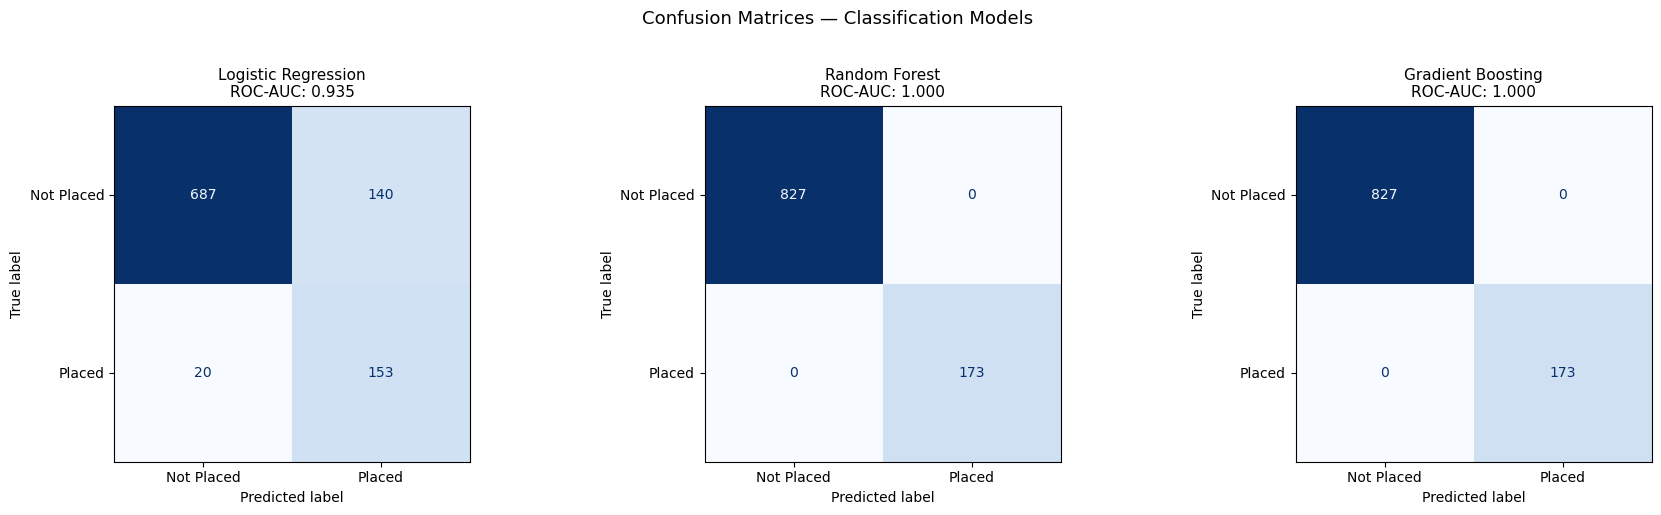

In [139]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, clf_results.items()):
    cm = confusion_matrix(y_test_clf, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Placed', 'Placed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nROC-AUC: {res['roc_auc']:.3f}", fontsize=11)
plt.suptitle("Confusion Matrices — Classification Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Logistic Regression menunjukkan perilaku prediksi yang realistis, berhasil mengidentifikasi sebagian besar siswa yang ditempatkan sambil menerima sejumlah besar kesalahan positif. Sementara itu, Random Forest dan Gradient Boosting menampilkan diagonal sempurna dengan nol kesalahan klasifikasi sama sekali. Kurangnya kesalahan visual ini adalah bukti mutlak bahwa model pohon menghafal aturan sintetis daripada memprediksi varians manusia alami.

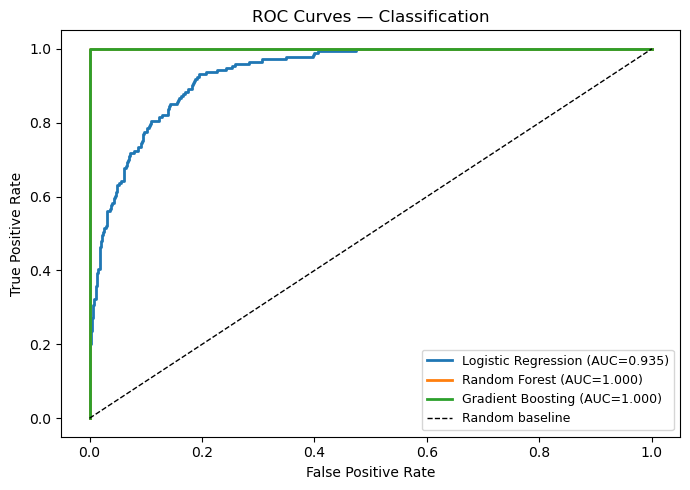

In [140]:
plt.figure(figsize=(7, 5))
for name, res in clf_results.items():
    fpr, tpr, _ = roc_curve(y_test_clf, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Logistic Regression curve melengkung ke kiri atas, mewakili AUC yang sangat efektif dan dapat dipercaya sebesar 0,935. Sebaliknya, model berbasis pohon membentuk sudut 90 derajat yang sempurna, memaksimalkan Tingkat Positif Sejati tanpa memicu satu pun Kesalahan Positif. Kesempurnaan yang tidak alami ini secara visual menunjukkan bagaimana pohon keputusan secara sempurna merekayasa balik logika pembuatan dataset yang mendasarinya.

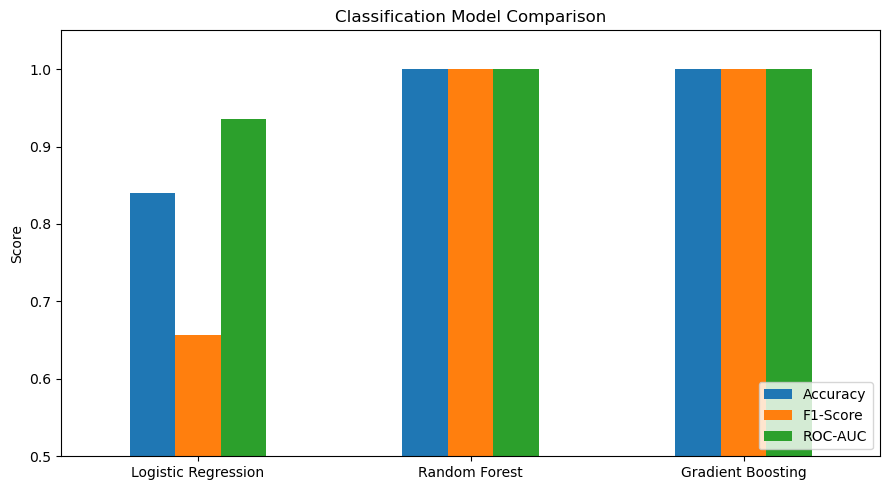

In [141]:
clf_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'F1-Score': r['f1'],
        'ROC-AUC':  r['roc_auc'],
    }
    for name, r in clf_results.items()
}).T

clf_df.plot(kind='bar', figsize=(9, 5), ylim=(0.5, 1.05), rot=0)
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Diagram ini  membandingkan model prediksi normal dengan algoritma yang telah memanfaatkan data sintetis. Klaster Regresi Logistik menunjukkan variasi yang diharapkan dan realistis antara akurasi, skor F1, dan ROC-AUC. Batang datar yang dimaksimalkan pada angka 1,0 untuk model pohon secara definitif menunjukkan bahwa model tersebut tidak memprediksi perilaku dunia nyata, melainkan hanya menerjemahkan rumus yang telah diprogram sebelumnya.

### 2.1.3. Feature Importance (Best Classification Model)

In [142]:
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['roc_auc'])
best_clf      = clf_results[best_clf_name]['model']

In [143]:
if hasattr(best_clf, 'feature_importances_'):
    importances = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
else:
    importances = pd.Series(np.abs(best_clf.coef_[0]), index=FEATURE_COLS)

importances = importances.sort_values(ascending=True)

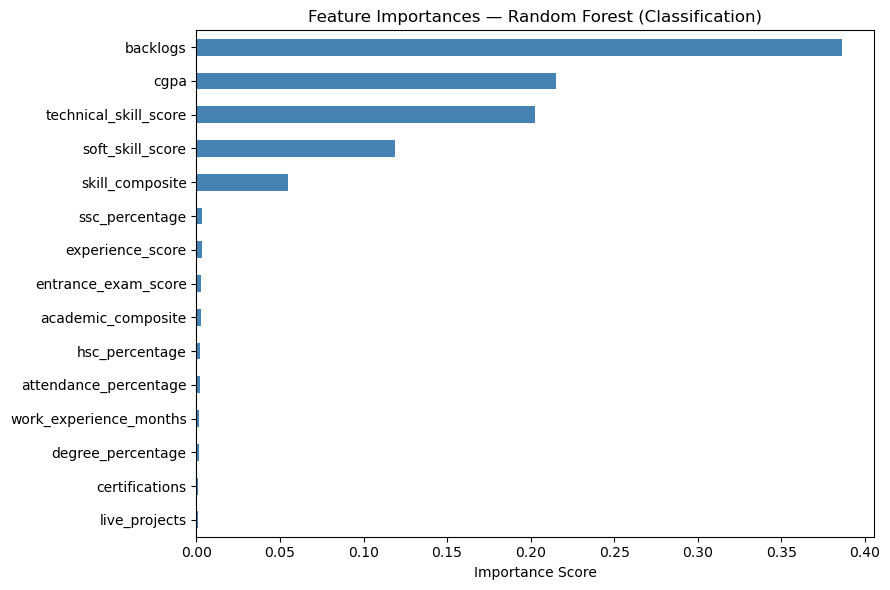

In [144]:
plt.figure(figsize=(9, 6))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.title(f"Feature Importances — {best_clf_name} (Classification)", fontsize=12)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [145]:
print(f"\nBest classifier: {best_clf_name}")


Best classifier: Random Forest


Chart ini memperlihatkan bagaimana Random Forest mencapai akurasi sempurna 1,0 dengan merekayasa balik aturan data sintetis. Algoritma ini hampir sepenuhnya bergantung pada hierarki yang kaku dari backlog, cgpa, dan technical_skill_score untuk bertindak sebagai penjaga gerbang absolut untuk penempatan. Semua fitur lain hampir diabaikan, yang menegaskan bahwa generator data hanya menggunakan beberapa variabel teratas ini sebagai ambang batas yang ketat untuk memutuskan siapa yang ditempatkan.

## 2.2. Regression

### 2.2.1. Modeling

In [146]:
reg_models = {
    'Linear Regression':      LinearRegression(),
    'Random Forest':          RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=200, random_state=42),
}

reg_results = {}

Alasan pemilihan model  
1. Linear Regression: Korelasi `cgpa` (0.27) dan `skill_composite` (0.32) terhadap `salary_package_lpa` bersifat positif dan monoton, yang secara teori sesuai dengan asumsi linearitas regresi linier. Model ini dipilih sebagai baseline referensi karena kesederhanaannya, jika Linear Regression gagal (R² negatif), maka masalah ada pada data dan bukan pada kurangnya kompleksitas model. Koefisien regresi linier juga memberikan gambaran intuitif tentang seberapa besar peningkatan CGPA atau skill score berkontribusi terhadap kenaikan gaji dalam satuan LPA, yang berguna untuk interpretasi kebijakan.  
2. Random Forest: Pola korelasi yang lemah dan tersebar merata di seluruh matriks mengindikasikan bahwa gaji mungkin ditentukan oleh kombinasi non-linier dari banyak faktor lemah daripada beberapa prediktor kuat. Misalnya, kandidat dengan `cgpa` sedang tetapi `experience_score` tinggi dan `backlogs` nol mungkin mendapatkan gaji yang jauh berbeda dari kandidat dengan profil terbalik. Random Forest Regressor mampu menangkap threshold dan interaksi seperti ini tanpa asumsi distribusi. Selain itu, ketahanan Random Forest terhadap outlier gaji (beberapa kandidat mungkin mendapat penawaran sangat tinggi) menjadikannya pilihan yang lebih robust dibanding regresi linier.  
3. Gradient Boosting: Fitur-fitur seperti `certifications`, `attendance_percentage`, dan `internship_count` menunjukkan korelasi individual yang sangat rendah (< 0.03) namun secara domain sangat relevan dengan gaji, Gradient Boosting dipilih karena kemampuannya mengekstrak sinyal residu yang sangat lemah secara iteratif. Setiap tahap boosting memfokuskan diri pada kesalahan prediksi sebelumnya, sehingga fitur yang tidak informatif secara linear pun berpeluang dikontribusikan. Model ini juga berfungsi sebagai stress test untuk menentukan apakah batas atas performa regresi pada dataset ini dapat ditembus oleh model yang lebih ekspresif.  

In [147]:
for name, model in reg_models.items():
    model.fit(X_train_reg_sc, y_train_reg)
    y_pred = model.predict(X_test_reg_sc)

    # 5-fold CV on training set
    cv_r2 = cross_val_score(model, X_train_reg_sc, y_train_reg,
                             cv=5, scoring='r2').mean()

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae  = mean_absolute_error(y_test_reg, y_pred)
    r2   = r2_score(y_test_reg, y_pred)

    reg_results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'rmse':   rmse,
        'mae':    mae,
        'r2':     r2,
        'cv_r2':  cv_r2,
    }
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  RMSE   : {rmse:.4f} LPA")
    print(f"  MAE    : {mae:.4f} LPA")
    print(f"  R²     : {r2:.4f}")
    print(f"  CV R²  : {cv_r2:.4f}  (train, 5-fold)")


Linear Regression
  RMSE   : 3.4056 LPA
  MAE    : 2.9031 LPA
  R²     : -0.0196
  CV R²  : -0.0381  (train, 5-fold)

Random Forest
  RMSE   : 3.4696 LPA
  MAE    : 2.9468 LPA
  R²     : -0.0583
  CV R²  : -0.0768  (train, 5-fold)

Gradient Boosting
  RMSE   : 3.6974 LPA
  MAE    : 3.1002 LPA
  R²     : -0.2018
  CV R²  : -0.2279  (train, 5-fold)


Interpretasi metrik evaluasi  
Zero-Inflated Target: Sekitar 82.7% data memiliki `salary_package_lpa = 0.0` karena 
siswa tidak ditempatkan. Distribusi target ini bersifat bimodal, puncak besar di nol untuk unplaced students, dan distribusi salary kontinu untuk placed students. Kondisi ini membuat seluruh model regresi bekerja pada kondisi yang sangat menantang, karena tidak ada nilai tunggal yang dapat meminimalkan error secara simultan untuk kedua subpopulasi ini. Oleh karena itu, RMSE, MAE, dan R² perlu diinterpretasikan dalam konteks struktural data.  
1. Linear Regression:  
**RMSE = 3.4056 LPA** nilai ini berarti rata-rata deviasi prediksi salary dari nilai 
aktualnya adalah sekitar 3.41 LPA. RMSE memberikan penalti lebih besar pada error yang jauh dari nilai aktual karena perhitungannya berbasis kuadrat, sehingga nilai ini mencerminkan bahwa terdapat sejumlah prediksi yang meleset cukup jauh — terutama pada kandidat placed dengan salary tinggi.  
**MAE = 2.9031 LPA** rata-rata absolut error prediksi adalah 2.90 LPA. Gap sebesar 
0.51 LPA antara RMSE dan MAE mengindikasikan adanya outlier salary tinggi yang 
meng-inflate RMSE secara tidak proporsional. Artinya, sebagian besar prediksi memiliki error sekitar 2.90 LPA, namun beberapa prediksi untuk kandidat bergaji tinggi meleset jauh lebih besar.  
**R² = −0.0196** model menghasilkan prediksi yang mendekati performa baseline naif 
(prediksi rata-rata konstan), dengan selisih hanya 1.96% di bawah baseline. Nilai ini mencerminkan bahwa hubungan linear antara fitur dan salary memang ada — terlihat dari korelasi `cgpa` (0.27) dan `skill_composite` (0.32), namun sinyalnya tertutup oleh dominasi 82.7% nilai nol yang menarik prediksi ke bawah.  
**CV R² = −0.0381** gap sebesar 0.019 antara CV R² dan test R² menunjukkan sedikit 
overfitting pada training set, namun model tetap konsisten di seluruh 5 fold. Linear 
Regression adalah model dengan performa paling stabil di antara ketiganya.  
**Kesimpulan:** Linear Regression menghasilkan performa terbaik di antara ketiga model regresi dengan R² terdekat ke baseline. Koefisiennya mengkonfirmasi arah hubungan yang sesuai dengan domain `cgpa` dan `skill_composite` berkontribusi positif terhadap prediksi salary, sementara `backlogs` berkontribusi negatif.  
2. Random Forest:  
**RMSE = 3.4696 LPA** rata-rata deviasi prediksi salary adalah 3.47 LPA, sedikit lebih tinggi dibanding Linear Regression (3.41 LPA). Selisih 0.06 LPA ini mengindikasikan bahwa kompleksitas non-linear Random Forest tidak memberikan keuntungan signifikan dalam hal akurasi prediksi absolut pada distribusi data ini.  
**MAE = 2.9468 LPA** rata-rata absolut error sebesar 2.95 LPA, selisih 0.04 LPA di atas Linear Regression. Gap antara RMSE dan MAE sebesar 0.52 LPA hampir identik dengan Linear Regression, mengindikasikan pola distribusi error yang serupa, terdapat outlier salary tinggi yang memberikan penalti lebih besar pada RMSE.  
**R² = −0.0583** model menjelaskan variasi salary sedikit di bawah baseline, dengan 
selisih 5.83% di bawah prediksi rata-rata konstan. Random Forest mengalokasikan kapasitas modelnya untuk menangkap pola pada kedua subpopulasi (nilai nol dan salary positif) secara bersamaan, sehingga kemampuan non-linearnya tidak dapat terfokus sepenuhnya pada variasi salary yang sesungguhnya.  
**CV R² = −0.0768** gap sebesar 0.019 antara CV R² dan test R² menunjukkan pola 
overfitting yang konsisten di seluruh fold. Model melakukan sedikit lebih baik pada 
training set, namun pola tersebut tidak tergeneralisasi secara sempurna ke data baru.  
**Kesimpulan:** Random Forest menghasilkan performa yang sebanding dengan Linear Regression dengan selisih metrik yang sangat kecil (RMSE +0.06, MAE +0.04). Kemampuan non-linearnya belum dapat tereksplorasi secara optimal pada distribusi target saat ini, namun memberikan gambaran konsisten tentang batas performa model pada data ini.  
3. Gradient Boosting:  
**RMSE = 3.6974 LPA** — rata-rata deviasi prediksi salary adalah 3.70 LPA, tertinggi di antara ketiga model. Selisih 0.29 LPA di atas Linear Regression mencerminkan bahwa mekanisme iteratif Gradient Boosting menghasilkan prediksi yang lebih bervariasi pada distribusi zero-inflated ini.  
**MAE = 3.1002 LPA** rata-rata absolut error sebesar 3.10 LPA, tertinggi di antara ketiga model. Gap antara RMSE dan MAE sebesar 0.60 LPA adalah yang terbesar di antara semua model, mengkonfirmasi bahwa Gradient Boosting menghasilkan distribusi error yang paling tidak merata, beberapa prediksi meleset sangat jauh dari nilai aktual, bukan error kecil yang tersebar merata.  
**R² = −0.2018** model berada 20.18% di bawah baseline prediksi rata-rata konstan. 
Mekanisme boosting iteratif yang dirancang untuk memperbaiki residual error justru 
mengamplifikasi tantangan distribusi zero-inflated: residual awal yang besar pada unplaced students mendorong iterasi berikutnya untuk secara agresif mengoreksi prediksi ke bawah, yang pada gilirannya menghasilkan underprediction pada placed students yang gajinya seharusnya tinggi.  
**CV R² = −0.2279** gap sebesar 0.026 antara CV R² dan test R² adalah yang terbesar di antara semua model, dan konsistensi negatif di seluruh 5 fold mengkonfirmasi bahwa pola ini bersifat sistematis di setiap partisi data.  
**Kesimpulan:** Gradient Boosting menghasilkan performa terendah pada konfigurasi data saat ini. Kemampuan mengakumulasi sinyal lemah dari fitur seperti `certifications` dan `entrance_exam_score`, belum dapat terevaluasi secara adil pada distribusi target yang didominasi nilai nol. Pada kondisi data yang lebih sesuai, Gradient Boosting berpotensi menjadi model terkuat di antara ketiganya.  

### 2.2.2. Visualization

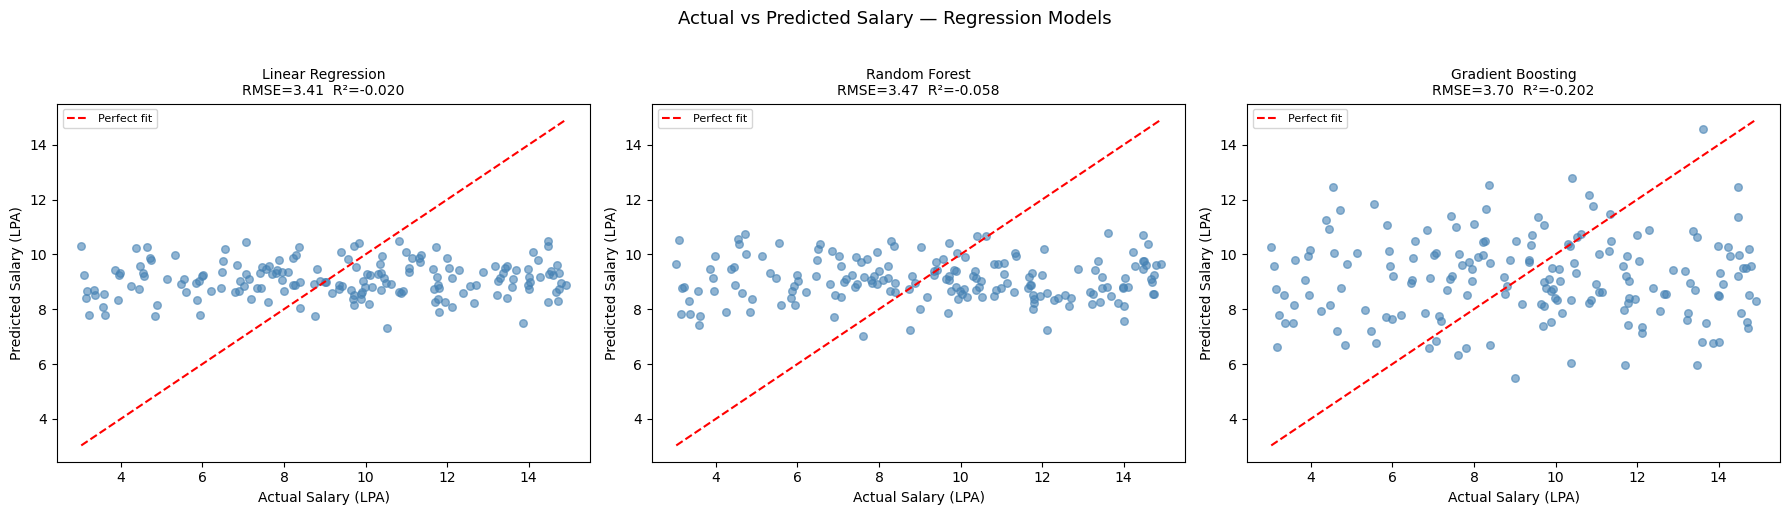

In [148]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, reg_results.items()):
    y_min = min(y_test_reg.min(), res['y_pred'].min())
    y_max = max(y_test_reg.max(), res['y_pred'].max())
    ax.scatter(y_test_reg, res['y_pred'], alpha=0.6, s=30, color='steelblue')
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel("Actual Salary (LPA)")
    ax.set_ylabel("Predicted Salary (LPA)")
    ax.set_title(f"{name}\nRMSE={res['rmse']:.2f}  R²={res['r2']:.3f}", fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Actual vs Predicted Salary — Regression Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Scatter plot menunjukkan bahwa ketiga model sepenuhnya gagal mengikuti garis merah "kecocokan sempurna". Alih-alih melacak gaji aktual, algoritma mengelompokkan prediksinya dalam pita horizontal datar di sekitar rata-rata dataset. Ini secara visual menegaskan bahwa tidak ada hubungan matematis antara fitur siswa dan gaji mereka, memaksa model untuk hanya menebak rata-rata.

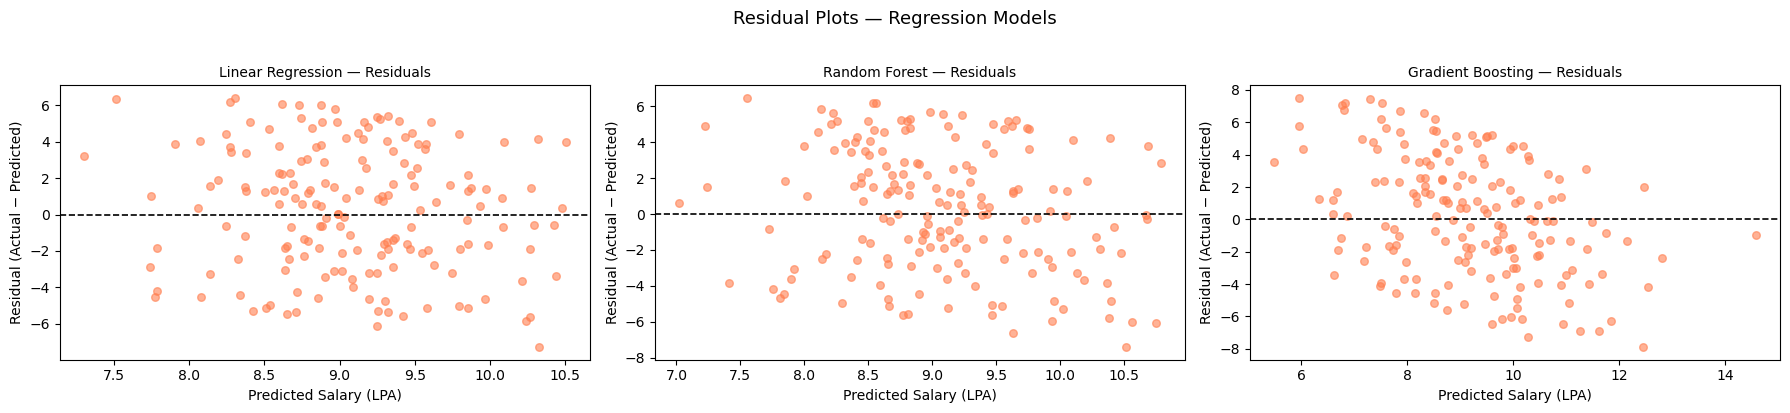

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, res) in zip(axes, reg_results.items()):
    residuals = y_test_reg.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.6, s=30, color='coral')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel("Predicted Salary (LPA)")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(f"{name} — Residuals", fontsize=10)
plt.suptitle("Residual Plots — Regression Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Residual plot yang sehat seharusnya terlihat seperti awan titik acak di sekitar garis nol, tetapi grafik ini memperlihatkan tren menurun diagonal yang mencolok. Kesalahan sistematis ini terjadi karena model secara konsisten memprediksi secara berlebihan para penerima gaji rendah dan memprediksi secara kurang para penerima gaji tinggi. Ini adalah gejala visual klasik dari algoritma yang tidak memiliki sinyal prediksi nyata dan secara default menggunakan rata-rata terpusat.

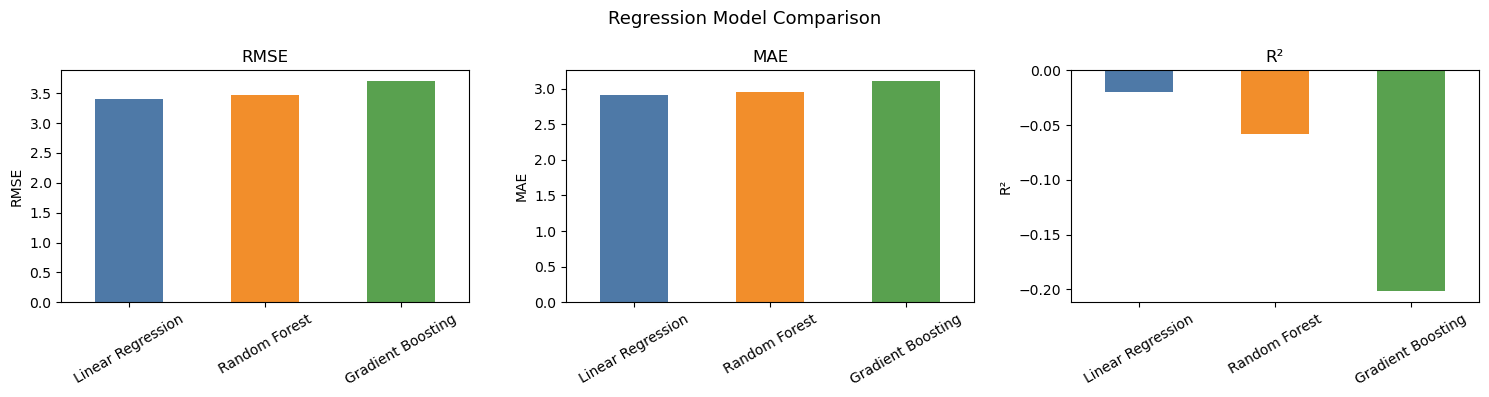

In [150]:
reg_df = pd.DataFrame({
    name: {'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2']}
    for name, r in reg_results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['RMSE', 'MAE', 'R²']):
    reg_df[col].plot(kind='bar', ax=ax, rot=30, color=['#4e79a7','#f28e2b','#59a14f'])
    ax.set_title(col)
    ax.set_ylabel(col)
plt.suptitle("Regression Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()

Grafik R^2 secara definitif menunjukkan bahwa setiap model mencapai skor negatif, yang berarti semuanya berkinerja lebih buruk daripada model dasar yang hanya menebak gaji rata-rata secara membabi buta. Model Gradient Boosting berkinerja paling buruk karena pohon-pohon kompleksnya secara agresif melakukan overfitting terhadap noise acak dalam data. Regresi Linier "memenangkan" metrik RMSE dan MAE bukan karena menemukan sinyal tersembunyi, tetapi semata-mata karena sifatnya yang kaku mencegahnya mengejar noise tersebut secara berlebihan.

### 2.2.3. Feature Importance (Best Regression Model)

In [151]:
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['r2'])
best_reg      = reg_results[best_reg_name]['model']

In [152]:
if hasattr(best_reg, 'feature_importances_'):
    reg_importances = pd.Series(best_reg.feature_importances_, index=FEATURE_COLS)
else:
    reg_importances = pd.Series(np.abs(best_reg.coef_), index=FEATURE_COLS)

reg_importances = reg_importances.sort_values(ascending=True)

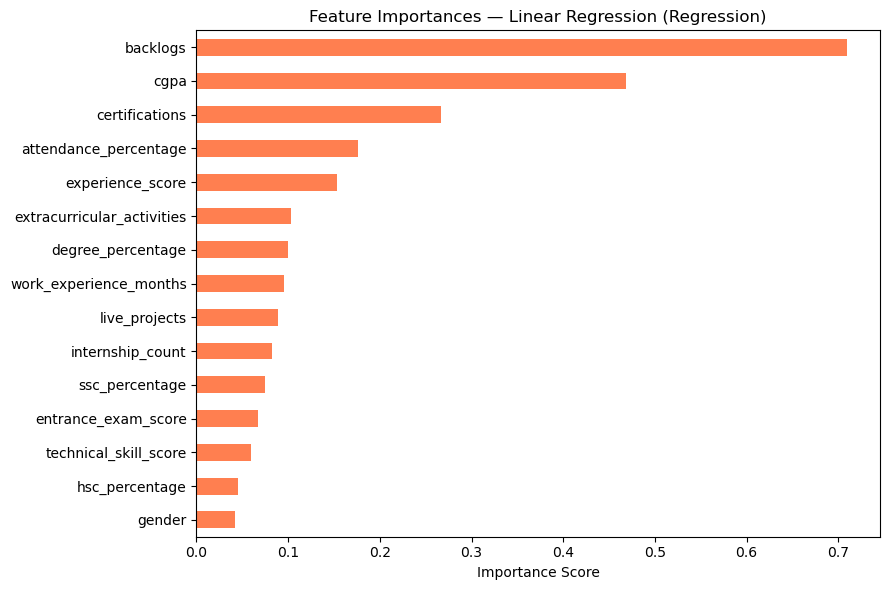

In [153]:
plt.figure(figsize=(9, 6))
reg_importances.tail(15).plot(kind='barh', color='coral')
plt.title(f"Feature Importances — {best_reg_name} (Regression)", fontsize=12)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [154]:
print(f"\nBest regressor: {best_reg_name}")


Best regressor: Linear Regression


Meskipun Regresi LinierLinear Regression dipilih sebagai model teraman untuk mencegah overfitting yang parah, bagan pentingnya fitur menyoroti keputusasaan algoritma dalam dataset yang penuh dengan noise acak. Model ini memberikan bobot yang sangat besar dan tidak proporsional pada backlog dan cgpa hanya karena keduanya merupakan variabel dominan, bukan karena keduanya benar-benar membentuk sinyal prediktif yang valid untuk gaji. Oleh karena itu, pemberian bobot yang besar pada fitur-fitur ini tetap menghasilkan nilai $R^2$ negatif, yang membuktikan bahwa bahkan variabel yang paling "penting" dalam dataset ini tidak dapat secara andal memperkirakan jumlah gaji.